In [2]:
# 1. Import Libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score

In [3]:
df = pd.read_csv("food_delivery_time.csv")
df

,Distance_km,Traffic_Level,Weather,Order_Size,Delivery_Time_Minutes
0,12.883448,Low,Rainy,7,38
1,3.504543,Low,Clear,6,58
2,1.761085,Medium,Rainy,5,50
3,6.061538,Medium,Rainy,6,27
4,4.855613,Medium,Clear,5,57
...,...,...,...,...,...
95,13.325227,Low,Clear,2,17
96,3.810080,Low,Foggy,1,22
97,6.896493,Low,Rainy,5,31
98,14.051883,High,Foggy,7,58


In [4]:
print(df.head())
print(df.info())

   Distance_km Traffic_Level Weather  Order_Size  Delivery_Time_Minutes
0    12.883448           Low   Rainy           7                     38
1     3.504543           Low   Clear           6                     58
2     1.761085        Medium   Rainy           5                     50
3     6.061538        Medium   Rainy           6                     27
4     4.855613        Medium   Clear           5                     57
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Distance_km            100 non-null    float64
 1   Traffic_Level          100 non-null    object 
 2   Weather                100 non-null    object 
 3   Order_Size             100 non-null    int64  
 4   Delivery_Time_Minutes  100 non-null    int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ KB
None


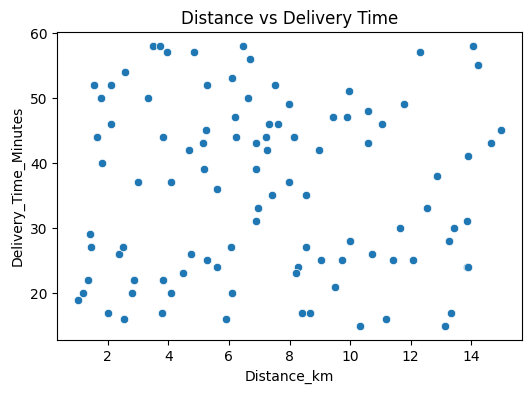

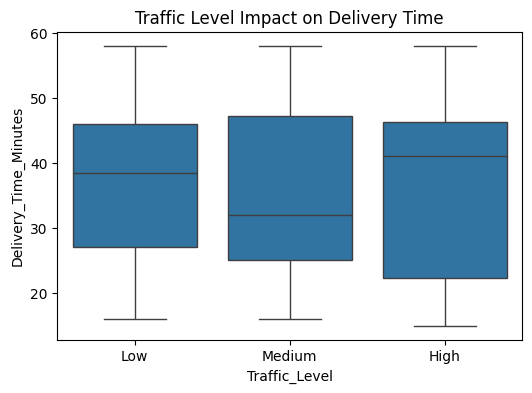

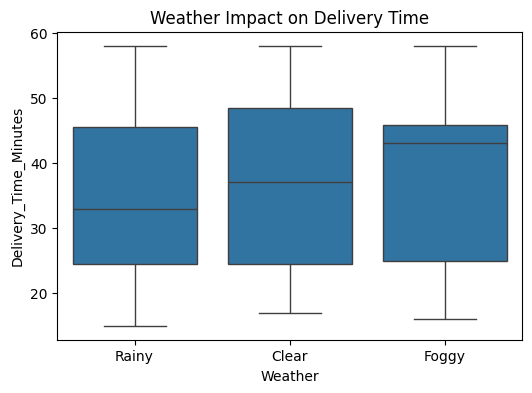

In [5]:
# Distance vs Delivery Time
plt.figure(figsize=(6,4))
sns.scatterplot(x="Distance_km", y="Delivery_Time_Minutes", data=df)
plt.title("Distance vs Delivery Time")
plt.show()

# Traffic level impact
plt.figure(figsize=(6,4))
sns.boxplot(x="Traffic_Level", y="Delivery_Time_Minutes", data=df)
plt.title("Traffic Level Impact on Delivery Time")
plt.show()

# Weather impact
plt.figure(figsize=(6,4))
sns.boxplot(x="Weather", y="Delivery_Time_Minutes", data=df)
plt.title("Weather Impact on Delivery Time")
plt.show()

In [6]:
le1 = LabelEncoder()
le2 = LabelEncoder()

df["Traffic_Level"] = le1.fit_transform(df["Traffic_Level"])
df["Weather"] = le2.fit_transform(df["Weather"])

In [7]:
X = df.drop("Delivery_Time_Minutes", axis=1)
y = df["Delivery_Time_Minutes"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)



In [9]:
# 7. Train Model

model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
# 8. Prediction

y_pred = model.predict(X_test)


In [14]:
# 9. Model Evaluation

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 10.91435278841703
R2 Score: -0.19490909792422184


In [15]:
# 10. Predict New Delivery Time

new_order = [[5, 1, 0, 4]] 
# Distance=5km, Traffic=Medium(1), Weather=Clear(0), Order_Size=4

predicted_time = model.predict(new_order)

print("Predicted Delivery Time:", predicted_time[0], "minutes")

Predicted Delivery Time: 38.80027815131263 minutes


C:\Users\shin9\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
